<a href="https://colab.research.google.com/github/ImrulMir15/cocomo-analysis/blob/main/Cocomo_Analysis_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""This notebook assumes scipy, pandas, numpy, matplotlib, and scikit-learn
are already installed (e.g., via `pip install -r requirements.txt`)."""

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import arff
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split,
)
from sklearn.tree import DecisionTreeRegressor

plt.style.use("ggplot")

In [ ]:
DATA_PATH = Path("cocomo811.arff")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH.resolve()}")

raw_data, meta = arff.loadarff(DATA_PATH)
columns = meta.names()
numeric_data = np.asarray(raw_data.tolist(), dtype=np.float64)
df = pd.DataFrame(numeric_data, columns=columns)
feature_names = columns[:-1]
target_name = columns[-1]

In [ ]:
df.shape

(63, 17)

In [ ]:
df.head()

In [ ]:
df.describe().T

In [ ]:
corr_with_target = df.corr(numeric_only=True)[target_name].sort_values(ascending=False)
corr_with_target

(63, 16)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[target_name], bins=15, color="tab:blue", edgecolor="black")
axes[0].set_title(f"Distribution of {target_name}")
axes[0].set_xlabel(target_name)
axes[0].set_ylabel("Frequency")
axes[1].boxplot(df[target_name], vert=False)
axes[1].set_title(f"{target_name} spread")
axes[1].set_xlabel(target_name)
plt.tight_layout()
plt.show()


X = df[feature_names].to_numpy(dtype=np.float64)
y = df[target_name].to_numpy(dtype=np.float64)
X.shape, y.shape

In [ ]:

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

In [ ]:
def compute_effort_metrics(y_true, y_pred, threshold=0.25):
    """Return key effort-estimation metrics."""
    eps = 1e-8
    mre = np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), eps)
    mmre = mre.mean()
    mdmre = np.median(mre)
    pred = (mre < threshold).mean() * 100
    return {
        "MMRE": mmre,
        "MdMRE": mdmre,
        "Pred25": pred,
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

In [ ]:
feature_count = len(feature_names)
MMRE_list = []
MdMRE_list = []
Pred_list = []

for max_feat in range(1, min(feature_count, 16) + 1):
    model = RandomForestRegressor(
        n_estimators=100,
        max_features=max_feat,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = compute_effort_metrics(y_test, y_pred)
    MMRE_list.append(metrics["MMRE"])
    MdMRE_list.append(metrics["MdMRE"])
    Pred_list.append(metrics["Pred25"])


/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestregressor.py:222: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


In [ ]:
MMRE_list

[np.float64(0.7692942114934028),
 np.float64(0.7639773276040983),
 np.float64(0.7866629042704216),
 np.float64(0.7785459968109718),
 np.float64(0.7665434218091967),
 np.float64(0.7783025204024754),
 np.float64(0.7688582736357864),
 np.float64(0.7752472489634671),
 np.float64(0.7814670303570048),
 np.float64(0.7831898830249099)]

In [ ]:
MdMRE_list

[np.float64(0.7730118821306926),
 np.float64(0.8161390686035156),
 np.float64(0.8057266807556153),
 np.float64(0.8014722029368083),
 np.float64(0.8050000031789144),
 np.float64(0.8115853681796934),
 np.float64(0.8156097574931819),
 np.float64(0.7986249923706055),
 np.float64(0.821833340326945),
 np.float64(0.8086666742960612)]

In [ ]:
Pred_list

[0.0,
 5.263157894736842,
 0.0,
 0.0,
 5.263157894736842,
 0.0,
 5.263157894736842,
 0.0,
 0.0,
 0.0]

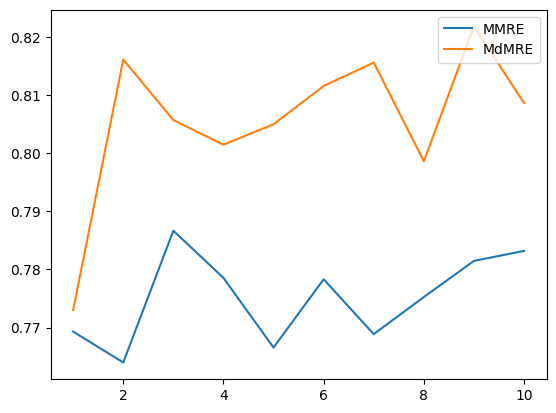

In [ ]:
x = np.arange(1, len(MMRE_list) + 1)

plt.plot(x, MMRE_list, marker="o")
plt.plot(x, MdMRE_list, marker="o")
plt.xlabel("max_features")
plt.ylabel("Error")
plt.legend(["MMRE", "MdMRE"], loc="upper right")
plt.show()

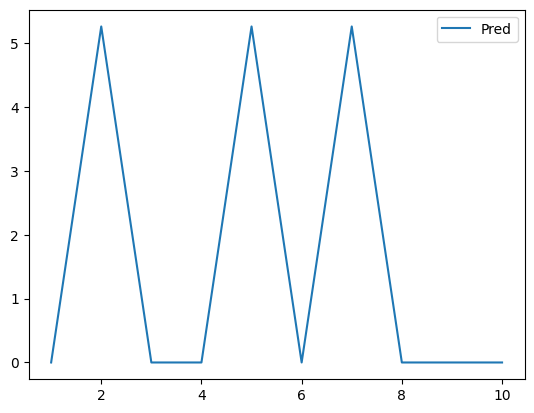

In [ ]:
plt.plot(x, Pred_list, marker="o", color="tab:green")
plt.xlabel("max_features")
plt.ylabel("Pred(25) %")
plt.legend(["Pred"], loc="upper right")
plt.show()

# COCOMO n_estimator=100 to 2000 and max_features= 7


In [ ]:
MMRE_list = []
MdMRE_list = []
Pred_list = []
for n_estimators in range(100, 1100, 100):
    model = RandomForestRegressor(
        n_estimators=n_estimators, max_features=7, random_state=RANDOM_STATE
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = compute_effort_metrics(y_test, y_pred)
    MMRE_list.append(metrics["MMRE"])
    MdMRE_list.append(metrics["MdMRE"])
    Pred_list.append(metrics["Pred25"])

In [ ]:
MMRE_list

[np.float64(0.7688582736357864),
 np.float64(0.7718198666653626),
 np.float64(0.771261420464998),
 np.float64(0.7732112560788668),
 np.float64(0.7714878277156594),
 np.float64(0.7697239955527306),
 np.float64(0.7702204529907979),
 np.float64(0.7703684875622279),
 np.float64(0.7709135546588088),
 np.float64(0.7704820728865027)]

In [ ]:
MdMRE_list

[np.float64(0.8156097574931819),
 np.float64(0.8178055604298909),
 np.float64(0.8178703784942627),
 np.float64(0.8149444580078125),
 np.float64(0.8161222298940023),
 np.float64(0.8175046443939209),
 np.float64(0.8175833384195964),
 np.float64(0.8200937430063884),
 np.float64(0.8186018466949463),
 np.float64(0.8199583371480306)]

In [ ]:
Pred_list

[5.263157894736842, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

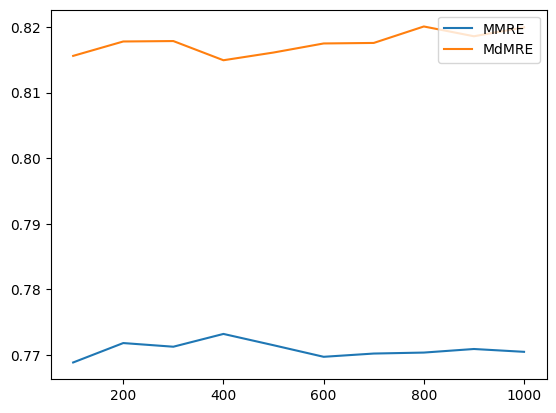

In [ ]:
x = np.arange(100, 1100, 100)
plt.plot(x, MMRE_list, marker="o")
plt.plot(x, MdMRE_list, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Error")
plt.legend(["MMRE", "MdMRE"], loc="upper right")
plt.show()

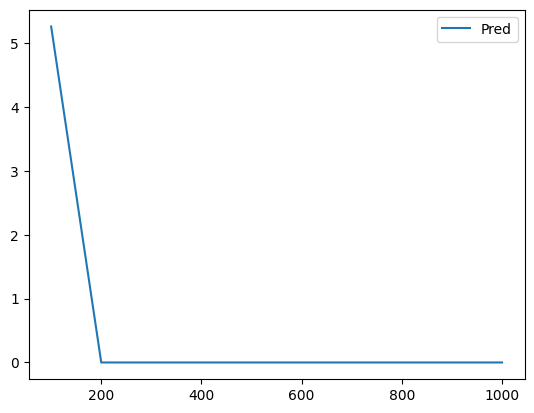

In [ ]:
plt.plot(x, Pred_list, marker="o", color="tab:green")
plt.xlabel("n_estimators")
plt.ylabel("Pred(25) %")
plt.legend(["Pred"], loc="upper right")
plt.show()

# GridSearchCV

In [ ]:
params_grd={
 'max_features': [1,2,3,4,5,6,7,8,9,10],
  'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000]}

In [ ]:
grid_model = RandomForestRegressor(random_state=RANDOM_STATE)
grd_search = GridSearchCV(
    estimator=grid_model,
    param_grid=params_grd,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=1,
)
grd_search.fit(X_train, y_train)
best_grid = grd_search.best_estimator_

y_pred = best_grid.predict(X_test)
grid_metrics = compute_effort_metrics(y_test, y_pred)
MMRE = grid_metrics["MMRE"]
MdMRE = grid_metrics["MdMRE"]
Pred = grid_metrics["Pred25"]


Fitting 2 folds for each of 100 candidates, totalling 200 fits


In [ ]:
grid_metrics

In [ ]:
grd_search.best_params_


# Random Hyperparameter Grid

In [ ]:
random_grid = {
    'bootstrap': [True, False],
    'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
    'max_features': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000],
}

In [ ]:
random_model = RandomForestRegressor(random_state=RANDOM_STATE)
random_search = RandomizedSearchCV(
    estimator=random_model,
    param_distributions=random_grid,
    n_iter=80,
    cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
random_search.fit(X_train, y_train)
best_random = random_search.best_estimator_

y_pred = best_random.predict(X_test)
random_metrics = compute_effort_metrics(y_test, y_pred)
MMRE = random_metrics["MMRE"]
MdMRE = random_metrics["MdMRE"]
Pred = random_metrics["Pred25"]


In [ ]:
random_metrics

In [ ]:
random_search.best_params_

#  Regression Tree Analysis

In [ ]:
tree = DecisionTreeRegressor(
    max_depth=30, min_samples_split=20, random_state=RANDOM_STATE
)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
tree_metrics = compute_effort_metrics(y_test, y_pred)

In [ ]:
tree_metrics

In [ ]:
model_summary = pd.DataFrame(
    {
        "GridSearch RF": grid_metrics,
        "RandomizedSearch RF": random_metrics,
        "Decision Tree": tree_metrics,
    }
).T
model_summary
